In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Suppress OSM download warnings
import warnings
warnings.filterwarnings("ignore")

## Kelurahan Boundaries

### Raw Data Check

In [4]:
jakarta_boundary = ox.geocode_to_gdf("DKI Jakarta, Indonesia")
jakarta_boundary = jakarta_boundary.to_crs("EPSG:32748")

In [7]:
kelurahan = ox.features_from_place(
    "DKI Jakarta, Indonesia",
    tags={"admin_level": "7", "boundary": "administrative"}
)

In [9]:
kelurahan.head()

geometry admin_level alt_name:ar  \
element id                                                               
node    1308636835  POINT (106.80393 -6.14459)           7         NaN   
        1308637440  POINT (106.90421 -6.16829)           7         NaN   
        1308637503  POINT (106.83122 -6.31031)           7         NaN   
        1308638331  POINT (106.81455 -6.15073)           7         NaN   
        1308638698  POINT (106.76097 -6.16855)           7         NaN   

                                   name name:af name:am name:ar name:arz  \
element id                                                                 
node    1308636835        Jembatan Lima     NaN     NaN     NaN      NaN   
        1308637440  Kelapa Gading Timur     NaN     NaN     NaN      NaN   
        1308637503            Kebagusan     NaN     NaN     NaN      NaN   
        1308638331            Keagungan     NaN     NaN     NaN      NaN   
        1308638698         Kedoya Utara     NaN     NaN     NaN      NaN   

                   name:as name:az  ... name:sr-Latn bat_name:smg  \
element id                          ...                             
node    1308636835     NaN     NaN  ...          NaN          NaN   
        1308637440     NaN     NaN  ...          NaN          NaN   
        1308637503     NaN     NaN  ...          NaN          NaN   
        1308638331     NaN     NaN  ...          NaN          NaN   
        1308638698     NaN     NaN  ...          NaN          NaN   

                   name:az-Arab name:bbc name:gor name:kk-Arab name:mad  \
element id                                                                
node    1308636835          NaN      NaN      NaN          NaN      NaN   
        1308637440          NaN      NaN      NaN          NaN      NaN   
        1308637503          NaN      NaN      NaN          NaN      NaN   
        1308638331          NaN      NaN      NaN          NaN      NaN   
        1308638698          NaN      NaN      NaN          NaN      NaN   

                   name:mai name:sat name:xmf  
element id                                     
node    1308636835      NaN      NaN      NaN  
        1308637440      NaN      NaN      NaN  
        1308637503      NaN      NaN      NaN  
        1308638331      NaN      NaN      NaN  
        1308638698      NaN      NaN      NaN  

[5 rows x 419 columns]

In [77]:
print(f"Raw download: {len(kelurahan)} rows")

Raw download: 32663 rows


In [81]:
print(type(kelurahan.index))
print(kelurahan.index)

<class 'pandas.MultiIndex'>
MultiIndex([('node', 1308636835),
            ('node', 1308637440),
            ('node', 1308637503),
            ('node', 1308638331),
            ('node', 1308638698),
            ('node', 1308640401),
            ('node', 1308641586),
            ('node', 1308641762),
            ('node', 1308643535),
            ('node', 1308643773),
            ...
            ( 'way', 1478722440),
            ( 'way', 1478722441),
            ( 'way', 1478722445),
            ( 'way', 1478724417),
            ( 'way', 1478724423),
            ( 'way', 1478724424),
            ( 'way', 1478724433),
            ( 'way', 1478724434),
            ( 'way', 1478737630),
            ( 'way', 1478737631)],
           names=['element', 'id'], length=32663)


In [83]:
print(kelurahan.index.names)

['element', 'id']


In [85]:
# Step 3 - Keep only relations (authoritative boundaries)
kelurahan = kelurahan[
    kelurahan.index.get_level_values("element") == "relation"
].copy()

In [109]:
kelurahan = kelurahan[
    kelurahan.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

In [117]:
kelurahan = kelurahan[["name", "geometry"]].copy()

In [119]:
kelurahan = kelurahan.to_crs("EPSG:32748")

In [125]:
kelurahan = gpd.clip(kelurahan, jakarta_boundary)
print(f"After spatial clip: {len(kelurahan)} rows")

After spatial clip: 8299 rows


In [129]:
rt_rw_pattern = r"^(RT|RW)\s+\d+"
kelurahan = kelurahan[
    ~kelurahan["name"].str.match(rt_rw_pattern, na=False)
].copy()
print(f"After RT/RW filter: {len(kelurahan)} rows")

After RT/RW filter: 516 rows


In [131]:
kelurahan['name'].value_counts()

name
Daerah Khusus Ibukota Jakarta    7
Kepulauan Seribu                 5
Banten                           4
Kabupaten Tangerang              4
Jawa Barat                       4
                                ..
Pulau Payung Kecil               1
Pulau Tidung                     1
Pulau Panggang                   1
Pulau Kelapa                     1
Pulau Harapan                    1
Name: count, Length: 385, dtype: int64

In [133]:
exclude = [
    "Indonesia", "Banten", "Jawa", "Lampung", "Bangka",
    "Kantor", "Dinas", "Gedung", "Masjid", "Gereja",
    "Sekolah", "Rumah Sakit", "Pasar"
]
pattern = "|".join(exclude)
kelurahan = kelurahan[
    ~kelurahan["name"].str.contains(pattern, na=False, case=False)
].copy()
print(f"After keyword filter: {len(kelurahan)} rows")

After keyword filter: 491 rows


In [135]:
# Step 11 - Filter by area size
# Real kelurahan in Jakarta: roughly 0.5 km² to 15 km²
kelurahan["area_km2"] = kelurahan.area / 1e6
kelurahan = kelurahan[
    (kelurahan["area_km2"] >= 0.1) &
    (kelurahan["area_km2"] <= 20)
].copy()
print(f"After area filter: {len(kelurahan)} rows")

After area filter: 334 rows


In [137]:
# Step 12 - Drop nulls and duplicates
kelurahan = kelurahan.dropna(subset=["name"])
kelurahan = kelurahan.drop_duplicates(subset=["name"], keep="first")
kelurahan = kelurahan.reset_index(drop=True)

print(f"\nFinal kelurahan count: {len(kelurahan)}")
print(kelurahan["name"].head(20))


Final kelurahan count: 299
0        Pondok Kelapa
1          Pondok Kopi
2          Malaka Jaya
3          Malaka Sari
4          Pulo Gebang
5              Ciracas
6              Pekayon
7     Kelapa Dua Wetan
8              Susukan
9             Rambutan
10         Kramat Jati
11              Tengah
12             Makasar
13      Pondok Ranggon
14              Munjul
15             Cibubur
16               MABES
17                Setu
18           Cilangkap
19            Cipayung
Name: name, dtype: str


In [139]:
# Check all 299 names to find non-kelurahan entries
print(kelurahan["name"].to_string())

# Check area distribution to find outliers
print(kelurahan["area_km2"].describe())

# Find suspiciously small areas (likely RT/RW slipping through)
print(kelurahan[kelurahan["area_km2"] < 0.3][["name", "area_km2"]])

# Find suspiciously large areas (likely kecamatan/city)
print(kelurahan[kelurahan["area_km2"] > 10][["name", "area_km2"]])

0                        Pondok Kelapa
1                          Pondok Kopi
2                          Malaka Jaya
3                          Malaka Sari
4                          Pulo Gebang
5                              Ciracas
6                              Pekayon
7                     Kelapa Dua Wetan
8                              Susukan
9                             Rambutan
10                         Kramat Jati
11                              Tengah
12                             Makasar
13                      Pondok Ranggon
14                              Munjul
15                             Cibubur
16                               MABES
17                                Setu
18                           Cilangkap
19                            Cipayung
20                               Ceger
21                          Bambu Apus
22                        Lubang Buaya
23                               Dukuh
24                        Pinang Ranti
25                Halim P

In [141]:
# Current filter: 0.1 - 20 km²
# Jakarta kelurahan average: ~1.5 km²
# Tighten the range

kelurahan = kelurahan[
    (kelurahan["area_km2"] >= 0.3) &   # removes tiny RT/RW
    (kelurahan["area_km2"] <= 15)       # removes large kecamatan
].copy()

print(f"After tighter area filter: {len(kelurahan)}")

After tighter area filter: 281


In [143]:
# Add more non-kelurahan keywords
exclude_more = [
    "MABES", "Markas", "Besar", "TNI", "Polri",
    "Tengah$",      # standalone "Tengah" but not "Jakarta Tengah"
    "Komplek", "Komplek",
    "Perumahan", "Taman",
    "Bandara", "Pelabuhan"
]

pattern = "|".join(exclude_more)
kelurahan = kelurahan[
    ~kelurahan["name"].str.contains(pattern, na=False, case=False)
].copy()

print(f"After additional keyword filter: {len(kelurahan)}")

After additional keyword filter: 273


<Axes: >

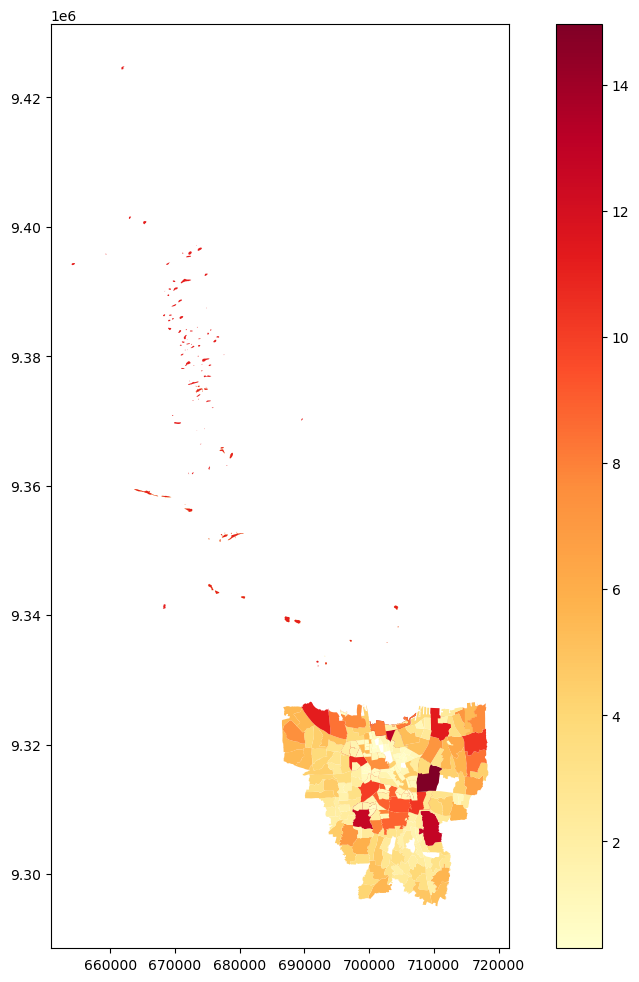

In [145]:
# Official DKI Jakarta kelurahan (267 total)
# Source: BPS DKI Jakarta

official_kecamatan = [
    "Gambir", "Sawah Besar", "Kemayoran", "Senen",
    "Cempaka Putih", "Menteng", "Tanah Abang", "Johar Baru",
    "Penjaringan", "Pademangan", "Tanjung Priok", "Koja",
    "Kelapa Gading", "Cilincing",
    "Kebayoran Baru", "Kebayoran Lama", "Pesanggrahan",
    "Cilandak", "Pasar Minggu", "Jagakarsa", "Mampang Prapatan",
    "Pancoran", "Tebet", "Setiabudi",
    "Matraman", "Pulo Gadung", "Jatinegara", "Duren Sawit",
    "Kramat Jati", "Makasar", "Pasar Rebo", "Cakung",
    "Cipayung", "Ciracas",
    "Tambora", "Taman Sari", "Palmerah", "Grogol Petamburan",
    "Kembangan", "Kebon Jeruk", "Cengkareng", "Kalideres"
]

# Check which of your kelurahan belong to valid kecamatan areas
# by plotting and visually verifying
kelurahan.plot(figsize=(12, 12),
               column="area_km2",
               cmap="YlOrRd",
               legend=True)

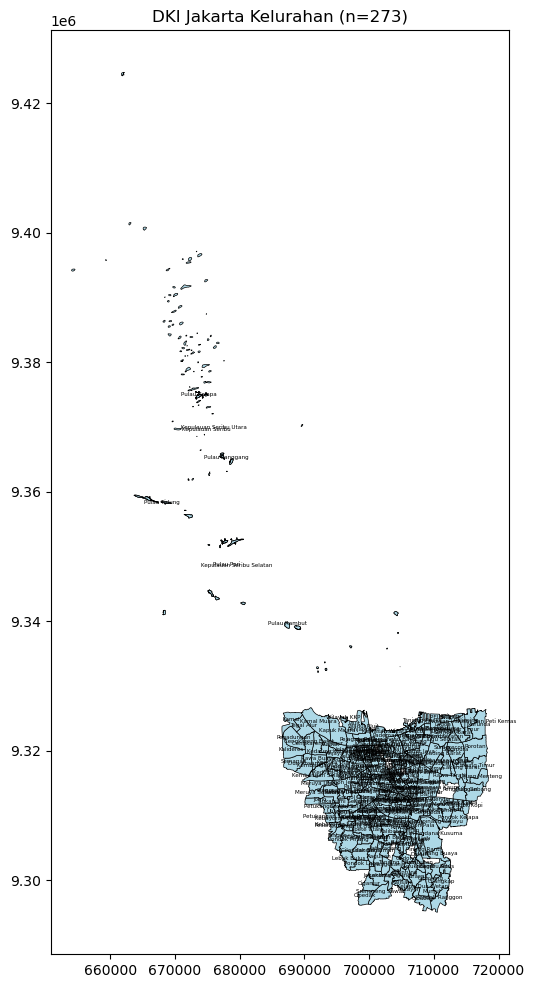

In [149]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

kelurahan.plot(ax=ax,
               color="lightblue",
               edgecolor="black",
               linewidth=0.5)

# Add names to each kelurahan
for idx, row in kelurahan.iterrows():
    ax.annotate(
        text=row["name"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=4,
        ha="center"
    )

plt.title(f"DKI Jakarta Kelurahan (n={len(kelurahan)})")
plt.show()

In [151]:
import geopandas as gpd
from shapely.geometry import box

# Step 1 - Remove by name keywords first
kepulauan_keywords = ["Pulau", "Seribu", "Tidung", "Pari",
                       "Panggang", "Harapan"]
pattern = "|".join(kepulauan_keywords)

kelurahan_main = kelurahan[
    ~kelurahan["name"].str.contains(pattern, na=False, case=False)
].copy()

print(f"After name filter    : {len(kelurahan_main)}")

# Step 2 - Then clip to main island bounding box
main_island_polygon = box(
    minx=106.65, miny=-6.40,
    maxx=107.00, maxy=-6.05
)

main_island_gdf = gpd.GeoDataFrame(
    geometry=[main_island_polygon],
    crs="EPSG:4326"
).to_crs("EPSG:32748")

# Use centroid to determine membership
kelurahan_main["centroid"] = kelurahan_main.geometry.centroid
kelurahan_main = kelurahan_main[
    kelurahan_main["centroid"].within(
        main_island_gdf.geometry.iloc[0]
    )
].copy()

kelurahan_main = kelurahan_main.drop(columns=["centroid"])
kelurahan_main = kelurahan_main.reset_index(drop=True)

print(f"After spatial filter : {len(kelurahan_main)}")
print(f"\nFinal count: {len(kelurahan_main)}")

After name filter    : 264
After spatial filter : 264

Final count: 264


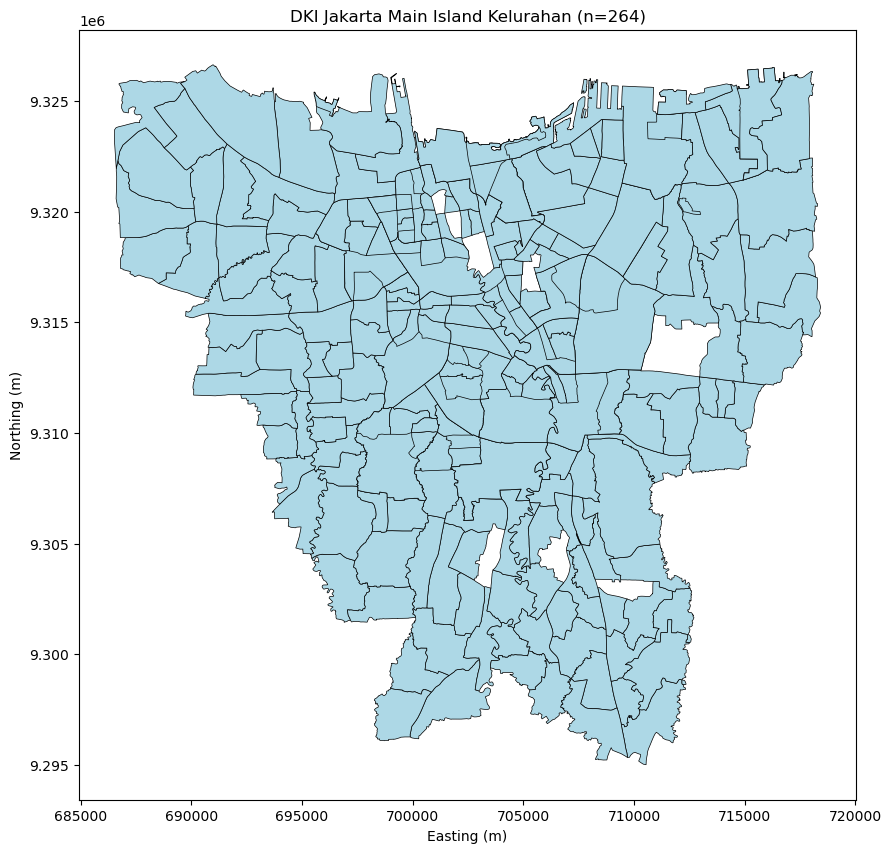

In [155]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

kelurahan_main.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=0.5
)

plt.title(f"DKI Jakarta Main Island Kelurahan (n={len(kelurahan_main)})")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

                     name   area_km2
178           Pulo Gadung  14.955029
231            Pademangan  13.137442
23   Halim Perdana Kusuma  12.835331
100        Kebayoran Baru  12.722129
247                  Koja  11.315303
261           Kamal Muara  11.218071
63      Grogol Petamburan  10.725845
237               Rorotan  10.350557
33             Jatinegara  10.339449
134           Tanah Abang  10.054718
count    264.000000
mean       2.910270
std        2.659800
min        0.303948
25%        1.072052
50%        1.987923
75%        3.924199
max       14.955029
Name: area_km2, dtype: float64


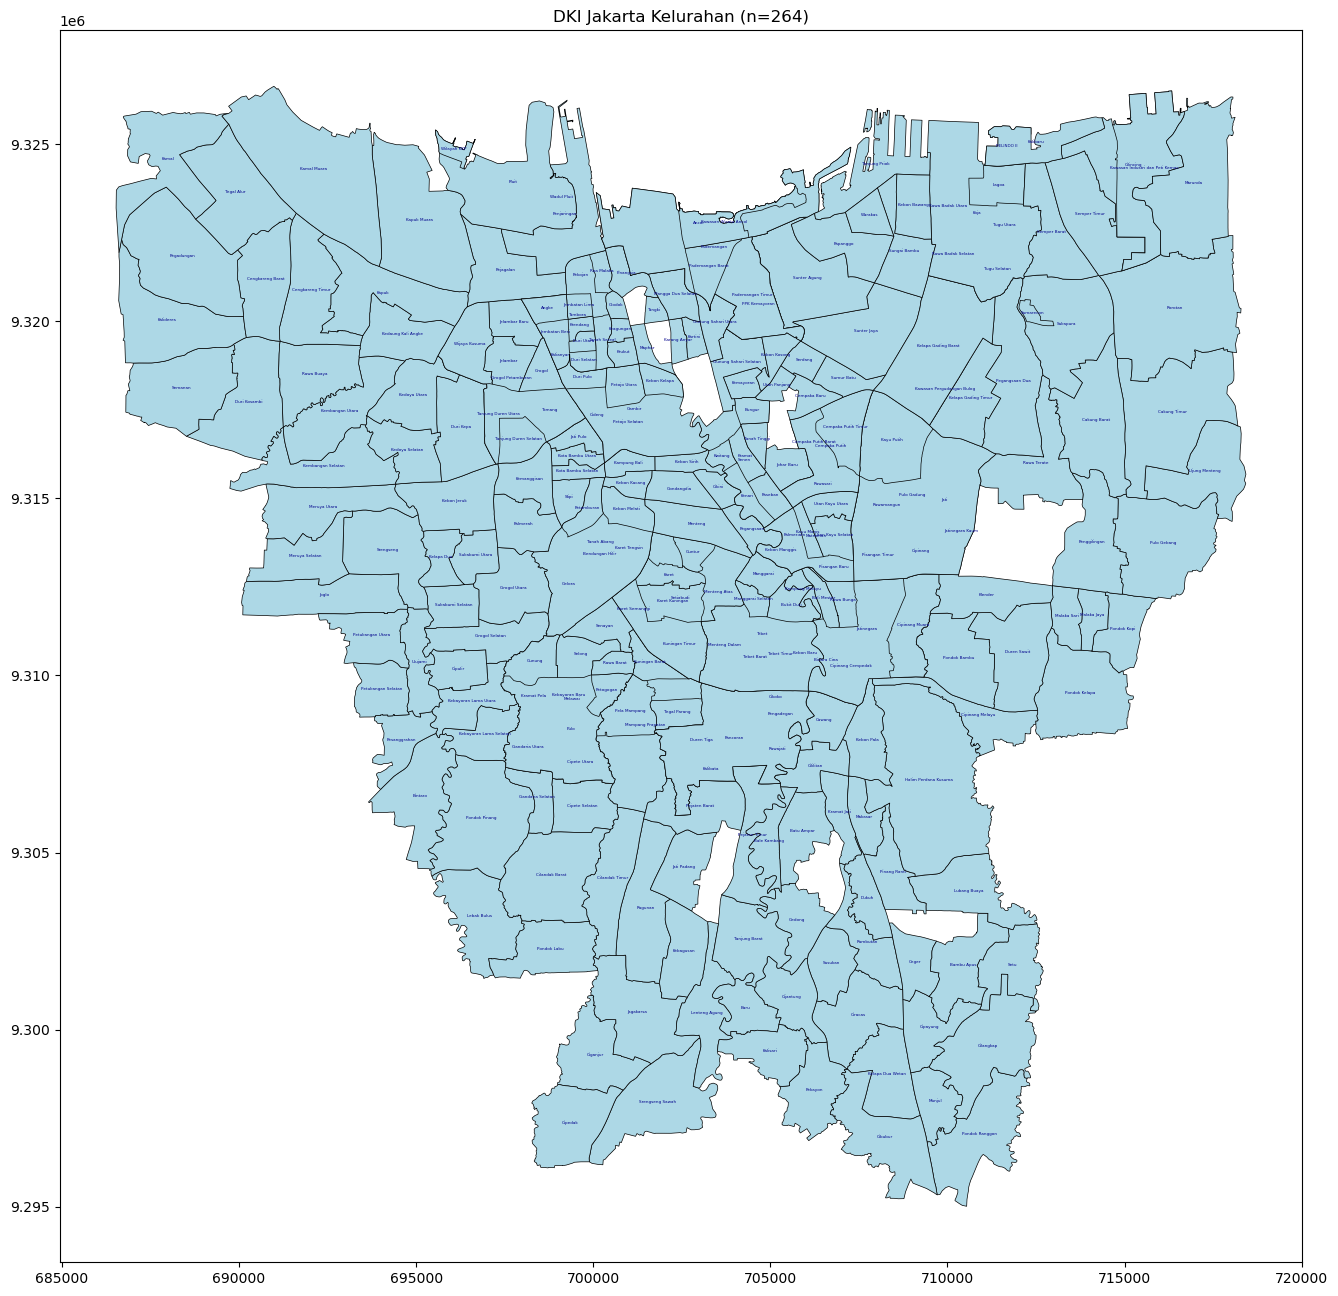

In [159]:
# 1. Check the 3 extra beyond expected 261
print(kelurahan_main[["name", "area_km2"]].sort_values(
    "area_km2", ascending=False).head(10))

# 2. Check area statistics
print(kelurahan_main["area_km2"].describe())

# 3. Plot with names to identify any non-kelurahan
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 16))
kelurahan_main.plot(ax=ax, 
                    color="lightblue",
                    edgecolor="black", 
                    linewidth=0.5)

# Add kelurahan names
for idx, row in kelurahan_main.iterrows():
    ax.annotate(
        text=row["name"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=3,
        ha="center",
        color="darkblue"
    )

plt.title(f"DKI Jakarta Kelurahan (n={len(kelurahan_main)})")
plt.show()

### Raw Data Boundaries 

In [43]:
# Step 1 - Keep only Polygon and MultiPolygon
kelurahan = kelurahan[
    kelurahan.geometry.type.isin(["Polygon", "MultiPolygon"])
]

In [51]:
# Step 2 - Check for duplicate names after geometry filter
print(kelurahan["name"].value_counts().head(10))

name
RT 01    434
RT 02    432
RT 04    430
RT 03    430
RT 05    425
RT 06    417
RT 07    394
RT 08    372
RT 09    347
RT 10    301
Name: count, dtype: int64


In [53]:
# Step 3 - If still duplicates, drop them
kelurahan = kelurahan.drop_duplicates(subset=["name"])

In [55]:
# Step 4 - Reset index
kelurahan = kelurahan.reset_index(drop=True)

In [57]:
# Step 5 - Verify
print(f"Final kelurahan count: {len(kelurahan)}")
# DKI Jakarta should have ~267 kelurahan

Final kelurahan count: 742


In [59]:
# Step 2 - Check for duplicate names after geometry filter
print(kelurahan["name"].value_counts().head(10))

name
Indonesia                    1
Banten                       1
Jawa Barat                   1
Lampung                      1
Kepulauan Bangka Belitung    1
RW 01                        1
RW 02                        1
RW 03                        1
RW 09                        1
Pondok Aren                  1
Name: count, dtype: int64


In [13]:
kelurahan = kelurahan[kelurahan.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

In [14]:
kelurahan = kelurahan[["name", "geometry"]].reset_index(drop=True)

In [13]:
kelurahan.drop_duplicates()

,name,geometry
0,Indonesia,"POLYGON ((95.78345 2.38085, 95.26483 2.80984, ..."
1,Banten,"POLYGON ((104.65132 -6.45503, 105.04891 -6.324..."
5,Jawa Barat,"POLYGON ((106.05095 -7.45659, 106.24081 -7.185..."
9,Lampung,"POLYGON ((103.50688 -5.51368, 103.59583 -4.922..."
12,Kepulauan Bangka Belitung,"POLYGON ((105.00529 -1.51384, 105.01221 -1.182..."
...,...,...
8641,Dinas Pertambangan DKI Jakarta (Unit Pengolaha...,"POLYGON ((106.57222 -5.65328, 106.57229 -5.653..."
8642,"Ancol, Kantor Lurah","POLYGON ((106.81717 -6.12383, 106.8174 -6.1238..."
8643,Kantor Lurah Semper Barat,"POLYGON ((106.92679 -6.12974, 106.92692 -6.129..."
8644,Dinas Sosial- Sasana Perlindungan Bhakti Kasih...,"POLYGON ((106.92421 -6.12606, 106.92433 -6.125..."


In [40]:
print(f"Kelurahan count: {len(kelurahan)}")

Kelurahan count: 8646


## Population Estimation

In [26]:
# Reproject to metric CRS first
CRS = "EPSG:32748"  # UTM Zone 48S in meter format
kelurahan = kelurahan.to_crs(CRS)

In [34]:
# Area-based population proxy (replace with WorldPop data if available)
# Assumes uniform density of ~15,000 people per km²  (Jakarta average)

kelurahan["area_km2"] = kelurahan.area / 1e6
kelurahan["population"] = (kelurahan["area_km2"] * 15000).round(0).astype(int)

In [36]:
print(kelurahan[["name", "area_km2", "population"]].head(5))
print(f"\nTotal estimated population: {kelurahan['population'].sum():,}")

        name      area_km2   population
0  Indonesia  5.841310e+06  87619644453
1     Banten  2.365469e+04    354820388
2     Banten  2.365469e+04    354820388
3     Banten  2.365469e+04    354820388
4     Banten  2.365469e+04    354820388

Total estimated population: 173,154,812,862
